GIAI ĐOẠN 1: XGBOOST BASELINE
Đang đọc, trích xuất Hình học, HOG, Color Histogram và LBP...
Đang chia tập dữ liệu đảm bảo Cân bằng Class và Chống Leakage...
Kích thước X_train: (12950, 2567)
Kích thước X_val:   (2796, 2567)
Kích thước X_test:  (2799, 2567)
Xử lý dữ liệu hoàn tất!

Đang huấn luyện Baseline (Có Early Stopping)...
[0]	validation_0-mlogloss:1.92497	validation_1-mlogloss:1.92691
[200]	validation_0-mlogloss:0.62663	validation_1-mlogloss:0.89666
[400]	validation_0-mlogloss:0.33466	validation_1-mlogloss:0.68746
[600]	validation_0-mlogloss:0.19990	validation_1-mlogloss:0.60255
[800]	validation_0-mlogloss:0.12382	validation_1-mlogloss:0.55865
[1000]	validation_0-mlogloss:0.08017	validation_1-mlogloss:0.53365
[1200]	validation_0-mlogloss:0.05344	validation_1-mlogloss:0.51929
[1400]	validation_0-mlogloss:0.03643	validation_1-mlogloss:0.51078
[1600]	validation_0-mlogloss:0.02549	validation_1-mlogloss:0.50687
[1800]	validation_0-mlogloss:0.01833	validation_1-mlogloss:0.50548
[1846]	

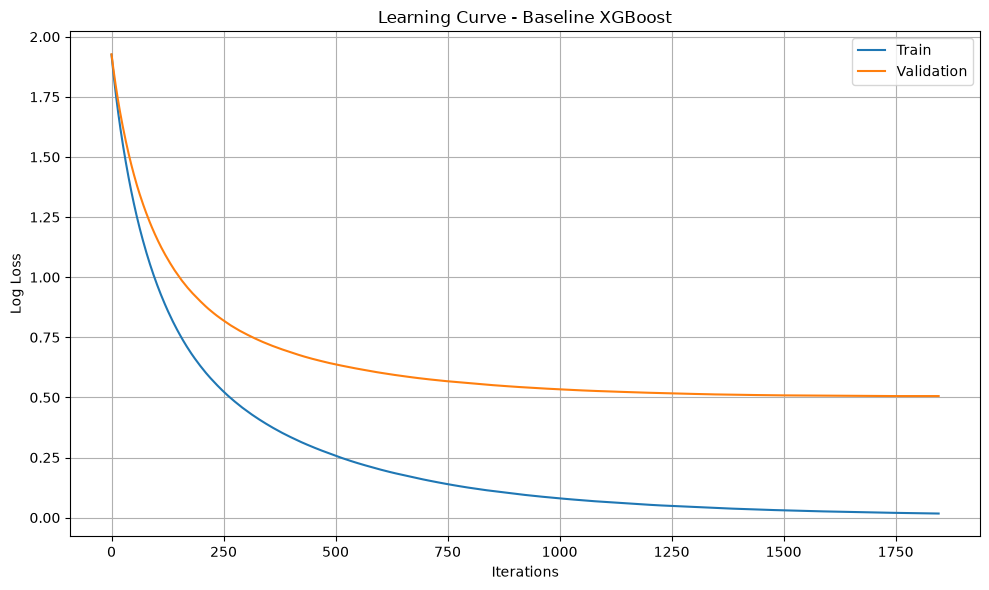

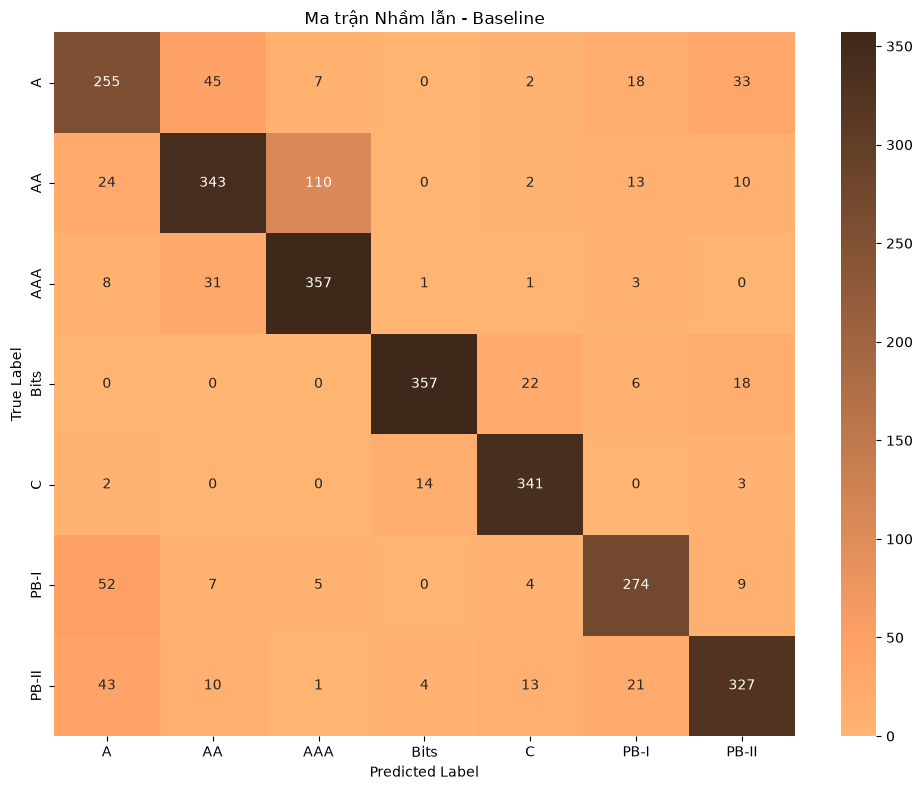


[SHAP] Đang tính SHAP (native XGBoost)...


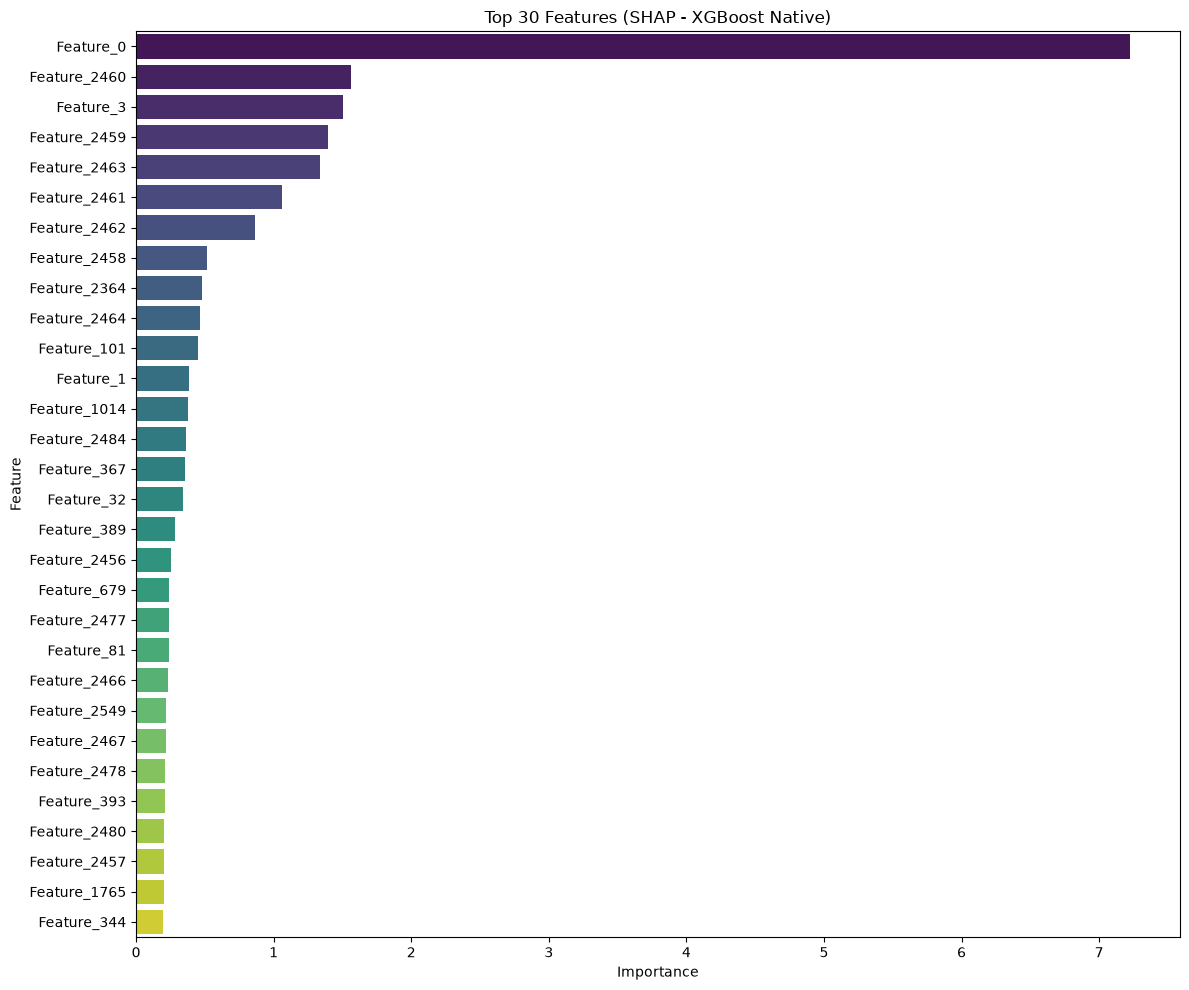

-> SHAP done in 109.77s

GIAI ĐOẠN 2: RETRAIN DỰA TRÊN TOP FEATURES TỪ SHAP

**************************************************
ĐANG XỬ LÝ VỚI TOP 500 FEATURES
**************************************************


XGBoostError: [01:02:17] C:\actions-runner\_work\xgboost\xgboost\src\data\quantile_dmatrix.cc:58: Check failed: ref->Info().num_col_ == n_features (500 vs. 2567) : Invalid ref DMatrix, different number of features.

In [ ]:
import time
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import xgboost as xgb

from matplotlib.colors import LinearSegmentedColormap
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score, classification_report, confusion_matrix
from Data_preprocessing_CBD import data_preprocessing

# =====================================================================
# UTILITIES
# =====================================================================

def truncate_colormap(cmap, minval=0.0, maxval=1.0, n=100):
    new_cmap = LinearSegmentedColormap.from_list(
        f'trunc({cmap.name},{minval:.2f},{maxval:.2f})',
        cmap(np.linspace(minval, maxval, n))
    )
    return new_cmap

def plot_confusion_matrix(y_true, y_pred, target_names, cmap, title='Confusion Matrix - XGBoost'):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap=cmap,
                xticklabels=target_names, yticklabels=target_names)
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.title(title)
    plt.tight_layout()
    plt.show()

def plot_loss_curve(model, title='Learning Curve - XGBoost'):
    results = model.evals_result()

    train_loss = results['validation_0']['mlogloss']
    val_loss   = results['validation_1']['mlogloss']

    plt.figure(figsize=(10, 6))
    plt.plot(train_loss, label='Train')
    plt.plot(val_loss, label='Validation')
    plt.legend()
    plt.title(title)
    plt.xlabel('Iterations')
    plt.ylabel('Log Loss')
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# =====================================================================
# NATIVE SHAP XGBOOST (QUAN TRỌNG NHẤT)
# =====================================================================

def get_shap_feature_importance_xgb(model, X_train, X_val, top_n=30):
    print("\n[SHAP] Đang tính SHAP (native XGBoost)...")
    start = time.time()

    dval = xgb.DMatrix(X_val)

    # Native SHAP
    shap_values = model.get_booster().predict(dval, pred_contribs=True)

    n_samples = X_val.shape[0]
    n_features = X_val.shape[1]
    n_classes = model.n_classes_

    # reshape (điểm khó nhất của XGB)
    shap_values = shap_values.reshape(
        n_samples,
        n_classes,
        n_features + 1
    )

    # bỏ base value
    shap_values = shap_values[:, :, :-1]

    # gộp multi-class giống CatBoost
    shap_importance = np.abs(shap_values).mean(axis=0).sum(axis=0)

    if hasattr(X_train, 'columns'):
        feature_names = X_train.columns
    else:
        feature_names = [f'Feature_{i}' for i in range(n_features)]

    feature_imp_df = pd.DataFrame({
        'Feature': feature_names,
        'Importance': shap_importance
    }).sort_values(by='Importance', ascending=False)

    top_features = feature_imp_df.head(top_n)

    plt.figure(figsize=(12, 10))
    sns.barplot(
        x='Importance',
        y='Feature',
        data=top_features,
        hue='Feature',
        palette='viridis',
        legend=False
    )
    plt.title(f'Top {top_n} Features (SHAP - XGBoost Native)')
    plt.tight_layout()
    plt.show()

    print(f"-> SHAP done in {time.time() - start:.2f}s")
    return feature_imp_df

# =====================================================================
# STAGE 1: BASELINE
# =====================================================================

print("="*50)
print("GIAI ĐOẠN 1: XGBOOST BASELINE")
print("="*50)

X_train, y_train, X_val, y_val, X_test, y_test = data_preprocessing()

target_names = ["A", "AA", "AAA", "Bits", "C", "PB-I", "PB-II"]

model_baseline = xgb.XGBClassifier(
    n_estimators=5000,      
    learning_rate=0.01,     
    random_state=42,
    n_jobs=-1,
    eval_metric='mlogloss',
    early_stopping_rounds=50,
)

print("\nĐang huấn luyện Baseline (Có Early Stopping)...")
model_baseline.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_val, y_val)],
    verbose=200,
)

# Predict
start_time = time.time()
y_pred_base = model_baseline.predict(X_val).flatten() 
end_time = time.time()
    
predict_time = end_time - start_time

print(f"Thời gian dự đoán (Inference Time): {predict_time:.4f} giây")

# Evaluation
print("\n--- ĐÁNH GIÁ (MACRO) ---")
print(f"Precision: {precision_score(y_val, y_pred_base, average='macro'):.4f}")
print(f"Recall:    {recall_score(y_val, y_pred_base, average='macro'):.4f}")
print(f"F1-score:  {f1_score(y_val, y_pred_base, average='macro'):.4f}")

print("\n--- ĐÁNH GIÁ (WEIGHTED) ---")
print(f"Precision: {precision_score(y_val, y_pred_base, average='weighted'):.4f}")
print(f"Recall:    {recall_score(y_val, y_pred_base, average='weighted'):.4f}")
print(f"F1-score:  {f1_score(y_val, y_pred_base, average='weighted'):.4f}")

print("\n--- TỔNG QUAN ---")
print(f"Accuracy:  {accuracy_score(y_val, y_pred_base):.4f}")

print("\n--- ĐỘ CHÍNH XÁC TỪNG LỚP ---")
print(classification_report(y_val, y_pred_base))

print("\n--- ĐANG HIỂN THỊ ĐỒ THỊ BASELINE ---")
copper_trunc = truncate_colormap(plt.cm.copper, 0.2, 0.9).reversed()
plot_loss_curve(model_baseline, title='Learning Curve - Baseline XGBoost')
plot_confusion_matrix(y_val, y_pred_base, target_names, cmap=copper_trunc, title='Ma trận Nhầm lẫn - Baseline')

# SHAP
all_importances_shap = get_shap_feature_importance_xgb(
    model_baseline, X_train, X_val, top_n=30
)


GIAI ĐOẠN 2: RETRAIN DỰA TRÊN TOP FEATURES TỪ SHAP

**************************************************
ĐANG XỬ LÝ VỚI TOP 500 FEATURES
**************************************************
[0]	validation_0-mlogloss:1.92510	validation_1-mlogloss:1.92692
[200]	validation_0-mlogloss:0.63914	validation_1-mlogloss:0.89249
[400]	validation_0-mlogloss:0.34939	validation_1-mlogloss:0.68191
[600]	validation_0-mlogloss:0.21567	validation_1-mlogloss:0.59723
[800]	validation_0-mlogloss:0.13733	validation_1-mlogloss:0.55404
[1000]	validation_0-mlogloss:0.09110	validation_1-mlogloss:0.53038
[1200]	validation_0-mlogloss:0.06243	validation_1-mlogloss:0.51703
[1400]	validation_0-mlogloss:0.04368	validation_1-mlogloss:0.51020
[1600]	validation_0-mlogloss:0.03097	validation_1-mlogloss:0.50520
[1800]	validation_0-mlogloss:0.02248	validation_1-mlogloss:0.50342
[2000]	validation_0-mlogloss:0.01685	validation_1-mlogloss:0.50273
[2011]	validation_0-mlogloss:0.01660	validation_1-mlogloss:0.50270

--- ĐÁNH GIÁ MÔ

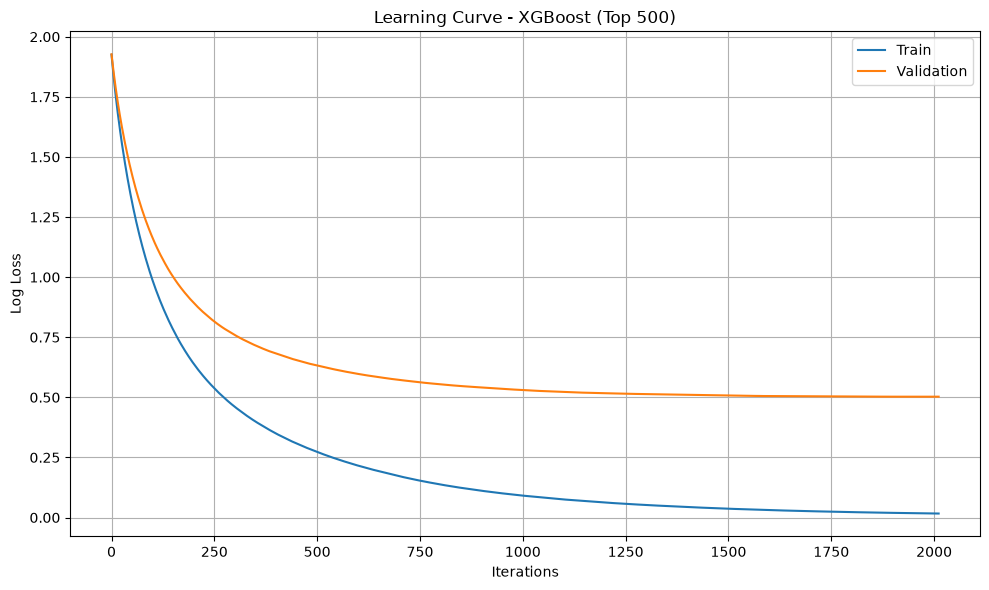

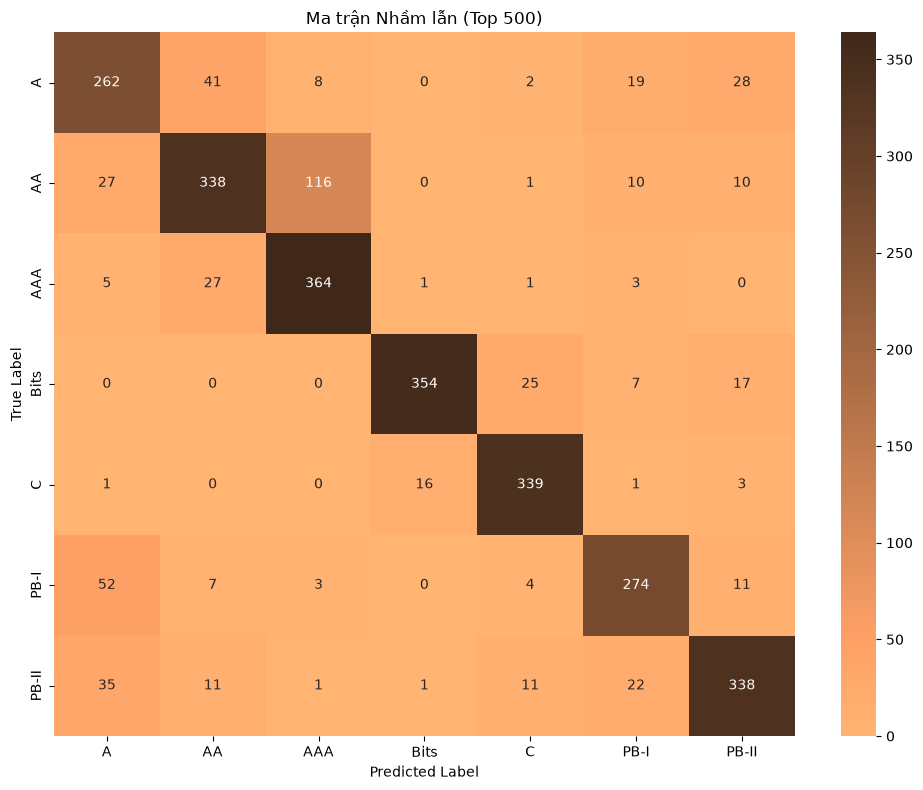


**************************************************
ĐANG XỬ LÝ VỚI TOP 1000 FEATURES
**************************************************
[0]	validation_0-mlogloss:1.92496	validation_1-mlogloss:1.92679
[200]	validation_0-mlogloss:0.63107	validation_1-mlogloss:0.89503
[400]	validation_0-mlogloss:0.33961	validation_1-mlogloss:0.68496
[600]	validation_0-mlogloss:0.20511	validation_1-mlogloss:0.59928
[800]	validation_0-mlogloss:0.12853	validation_1-mlogloss:0.55505
[1000]	validation_0-mlogloss:0.08395	validation_1-mlogloss:0.52938
[1200]	validation_0-mlogloss:0.05681	validation_1-mlogloss:0.51537
[1400]	validation_0-mlogloss:0.03920	validation_1-mlogloss:0.50718
[1600]	validation_0-mlogloss:0.02763	validation_1-mlogloss:0.50260
[1800]	validation_0-mlogloss:0.02002	validation_1-mlogloss:0.50014
[1988]	validation_0-mlogloss:0.01513	validation_1-mlogloss:0.49991

--- ĐÁNH GIÁ MÔ HÌNH MỚI (TOP 1000 FEATURES) ---
Thời gian dự đoán (Inference Time): 0.1791 giây

--- MACRO ---
Accuracy:  0.8104
Pre

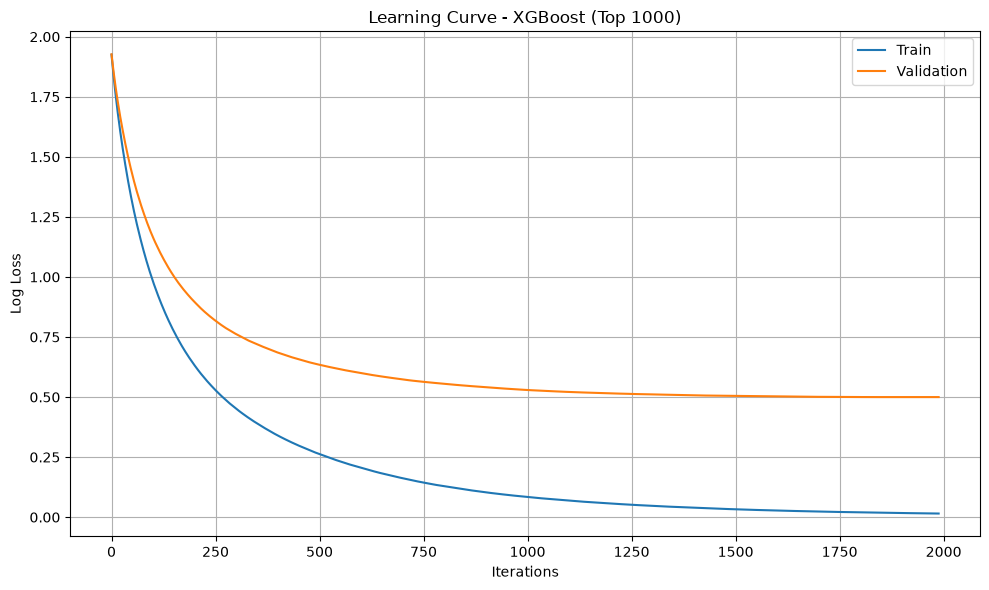

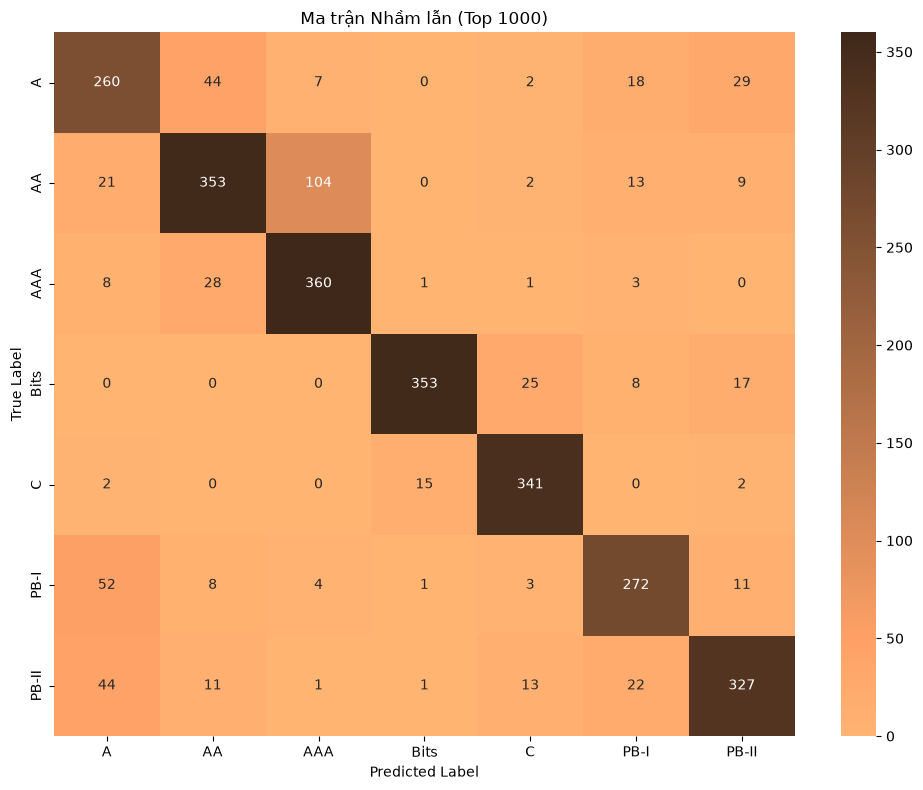


**************************************************
ĐANG XỬ LÝ VỚI TOP 1500 FEATURES
**************************************************
[0]	validation_0-mlogloss:1.92498	validation_1-mlogloss:1.92679
[200]	validation_0-mlogloss:0.62846	validation_1-mlogloss:0.89497
[400]	validation_0-mlogloss:0.33670	validation_1-mlogloss:0.68571
[600]	validation_0-mlogloss:0.20221	validation_1-mlogloss:0.60117
[800]	validation_0-mlogloss:0.12526	validation_1-mlogloss:0.55680
[1000]	validation_0-mlogloss:0.08136	validation_1-mlogloss:0.53158
[1200]	validation_0-mlogloss:0.05429	validation_1-mlogloss:0.51619
[1400]	validation_0-mlogloss:0.03716	validation_1-mlogloss:0.50786
[1600]	validation_0-mlogloss:0.02611	validation_1-mlogloss:0.50394
[1800]	validation_0-mlogloss:0.01890	validation_1-mlogloss:0.50290
[1837]	validation_0-mlogloss:0.01782	validation_1-mlogloss:0.50286

--- ĐÁNH GIÁ MÔ HÌNH MỚI (TOP 1500 FEATURES) ---
Thời gian dự đoán (Inference Time): 0.2132 giây

--- MACRO ---
Accuracy:  0.8115
Pre

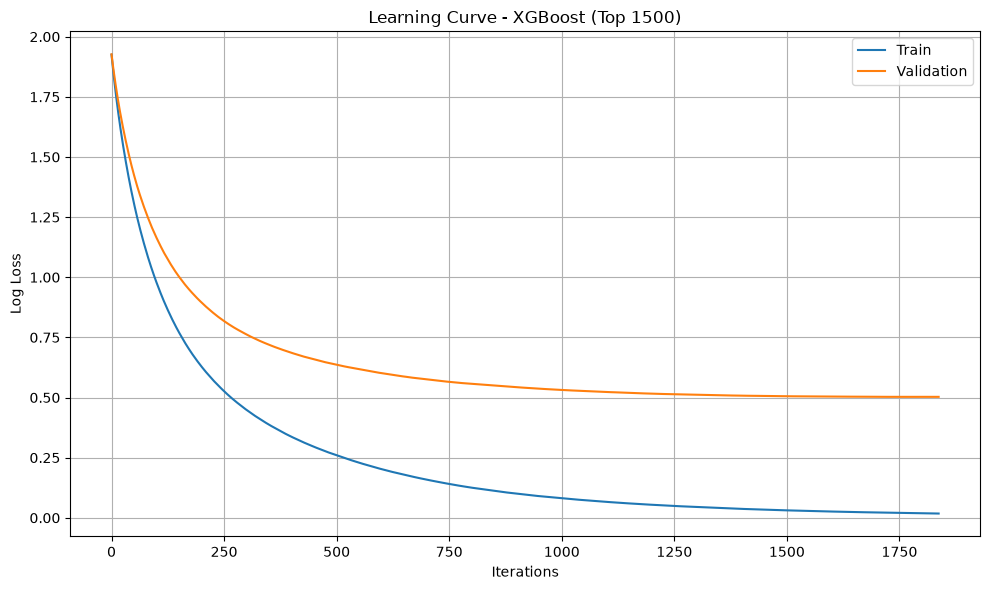

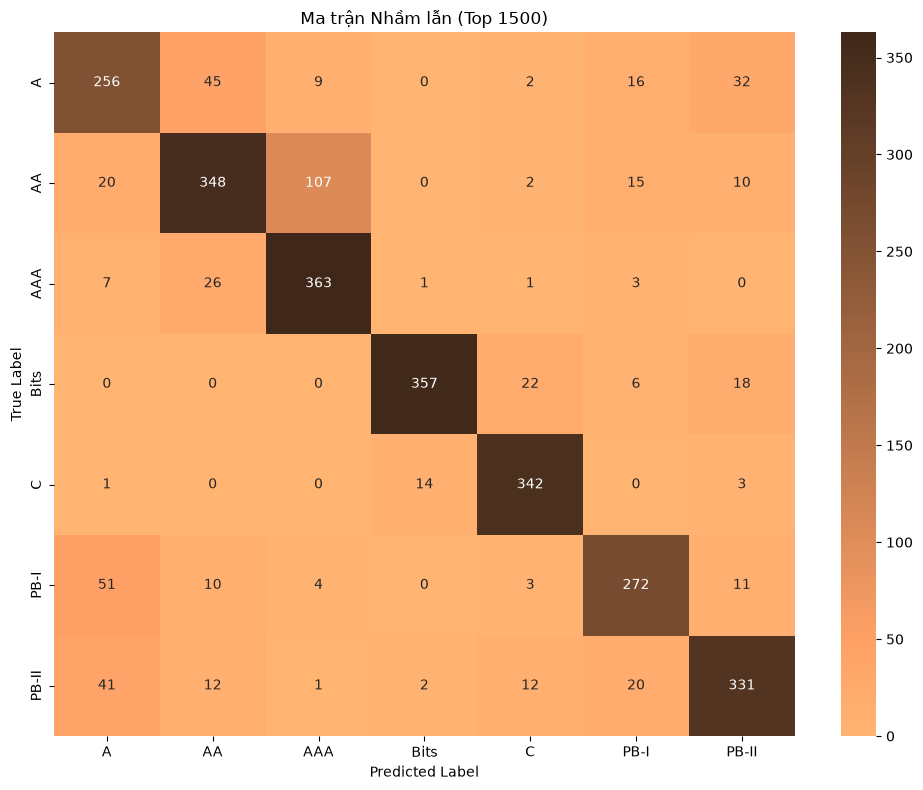

In [5]:
# =====================================================================
# STAGE 2: RETRAIN
# =====================================================================

print("\n" + "="*50)
print("GIAI ĐOẠN 2: RETRAIN DỰA TRÊN TOP FEATURES TỪ SHAP")
print("="*50)

top_ns = [500, 1000, 1500]

for top_n in top_ns:
    print(f"\n{'*'*50}")
    print(f"ĐANG XỬ LÝ VỚI TOP {top_n} FEATURES")
    print(f"{'*'*50}")

    important_features = all_importances_shap.head(top_n)

    if hasattr(X_train, 'columns'):
        selected_cols = important_features['Feature'].tolist()
        X_train_red = X_train[selected_cols]
        X_val_red   = X_val[selected_cols]
        X_test_red  = X_test[selected_cols]
    else:
        selected_idx = [int(f.split('_')[1]) for f in important_features['Feature']]
        X_train_red = X_train[:, selected_idx]
        X_val_red   = X_val[:, selected_idx]
        X_test_red  = X_test[:, selected_idx]

    model_final = xgb.XGBClassifier(
        n_estimators=4000,      
        learning_rate=0.01,     
        random_state=42,
        n_jobs=-1,
        eval_metric='mlogloss',
        early_stopping_rounds=50,
    )

    model_final.fit(
        X_train_red, y_train,
        eval_set=[(X_train_red, y_train), (X_val_red, y_val)],
        verbose=200,
    )

    start = time.time()
    y_pred_final = model_final.predict(X_val_red)
    predict_time = time.time() - start

    print(f"\n--- ĐÁNH GIÁ MÔ HÌNH MỚI (TOP {top_n} FEATURES) ---")
    print(f"Thời gian dự đoán (Inference Time): {predict_time:.4f} giây")

    print("\n--- MACRO ---")
    print(f"Accuracy:  {accuracy_score(y_val, y_pred_final):.4f}")
    print(f"Precision: {precision_score(y_val, y_pred_final, average='macro'):.4f}")
    print(f"Recall:    {recall_score(y_val, y_pred_final, average='macro'):.4f}")
    print(f"F1-score:  {f1_score(y_val, y_pred_final, average='macro'):.4f}")

    print("\n--- WEIGHTED ---")
    print(f"Precision: {precision_score(y_val, y_pred_final, average='weighted'):.4f}")
    print(f"Recall:    {recall_score(y_val, y_pred_final, average='weighted'):.4f}")
    print(f"F1-score:  {f1_score(y_val, y_pred_final, average='weighted'):.4f}")
    print("\n--- TỔNG QUAN ---")
    print(f"Accuracy:  {accuracy_score(y_val, y_pred_final):.4f}")
    print("\n--- ĐỘ CHÍNH XÁC TỪNG LỚP ---")
    print(classification_report(y_val, y_pred_final))
    
    # Vẽ đồ thị cho từng mô hình cắt giảm
    copper_trunc = truncate_colormap(plt.cm.copper, 0.2, 0.9).reversed()
    plot_loss_curve(model_final, title=f'Learning Curve - XGBoost (Top {top_n})')
    plot_confusion_matrix(y_val, y_pred_final, target_names, cmap=copper_trunc, title=f'Ma trận Nhầm lẫn (Top {top_n})')


**************************************************
ĐANG XỬ LÝ VỚI TOP 500 FEATURES
**************************************************
Đang huấn luyện mô hình (500 features)...

Đang dự đoán trên tập test...

--- ĐÁNH GIÁ MÔ HÌNH MỚI (TOP 500 FEATURES) ---
Thời gian dự đoán (Inference Time): 0.1781 giây

--- MACRO ---
Accuracy:  0.8482
Precision: 0.8464
Recall:    0.8514
F1-score:  0.8474

--- WEIGHTED ---
Precision: 0.8482
Recall:    0.8482
F1-score:  0.8467

--- TỔNG QUAN ---
Accuracy:  0.8482

--- ĐỘ CHÍNH XÁC TỪNG LỚP ---
              precision    recall  f1-score   support

           A       0.77      0.71      0.74       412
          AA       0.84      0.75      0.79       461
         AAA       0.79      0.91      0.84       354
        Bits       0.92      0.98      0.95       406
           C       0.96      0.94      0.95       411
        PB-I       0.86      0.81      0.83       403
       PB-II       0.80      0.86      0.83       352

    accuracy                      

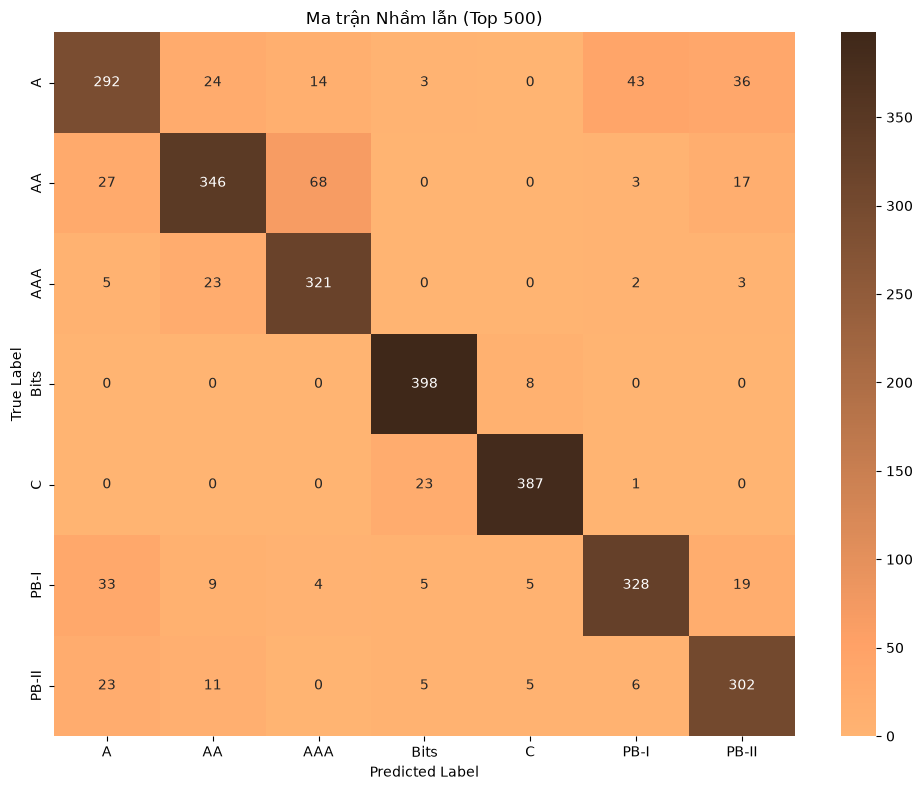

In [6]:
top_n = 500

print(f"\n{'*'*50}")
print(f"ĐANG XỬ LÝ VỚI TOP {top_n} FEATURES")
print(f"{'*'*50}")

important_features = all_importances_shap.head(top_n)

if hasattr(X_train, 'columns'):
    selected_cols = important_features['Feature'].tolist()
    X_train_red = X_train[selected_cols]
    X_val_red   = X_val[selected_cols]
    X_test_red  = X_test[selected_cols]
else:
    selected_idx = [int(f.split('_')[1]) for f in important_features['Feature']]
    X_train_red = X_train[:, selected_idx]
    X_val_red   = X_val[:, selected_idx]
    X_test_red  = X_test[:, selected_idx]

if hasattr(X_train_red, 'columns'):
    X_train_full = pd.concat([X_train_red, X_val_red], axis=0).reset_index(drop=True)
    y_train_full = pd.concat([pd.Series(y_train), pd.Series(y_val)], axis=0).reset_index(drop=True)
else:
    X_train_full = np.concatenate((X_train_red, X_val_red), axis=0)
    y_train_full = np.concatenate((y_train, y_val), axis=0)

model_final = xgb.XGBClassifier(
    n_estimators=2011,   
    learning_rate=0.01,     
    random_state=42,
    n_jobs=-1,
    eval_metric='mlogloss'
)

print(f"Đang huấn luyện mô hình ({top_n} features)...")
model_final.fit(
    X_train_full, y_train_full,
    verbose=200,
)

print(f"\nĐang dự đoán trên tập test...")
start = time.time()
y_pred_final = model_final.predict(X_test_red)
end = time.time()

predict_time = end - start

print(f"\n--- ĐÁNH GIÁ MÔ HÌNH MỚI (TOP {top_n} FEATURES) ---")
print(f"Thời gian dự đoán (Inference Time): {predict_time:.4f} giây")

print("\n--- MACRO ---")
print(f"Accuracy:  {accuracy_score(y_test, y_pred_final):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_final, average='macro'):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_final, average='macro'):.4f}")
print(f"F1-score:  {f1_score(y_test, y_pred_final, average='macro'):.4f}")

print("\n--- WEIGHTED ---")
print(f"Precision: {precision_score(y_test, y_pred_final, average='weighted'):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_final, average='weighted'):.4f}")
print(f"F1-score:  {f1_score(y_test, y_pred_final, average='weighted'):.4f}")
print("\n--- TỔNG QUAN ---")
print(f"Accuracy:  {accuracy_score(y_test, y_pred_final):.4f}")
print("\n--- ĐỘ CHÍNH XÁC TỪNG LỚP ---")
print(classification_report(y_test, y_pred_final, target_names=target_names))

# Vẽ đồ thị cho từng mô hình cắt giảm
copper_trunc = truncate_colormap(plt.cm.copper, 0.2, 0.9).reversed()
plot_confusion_matrix(y_test, y_pred_final, target_names, cmap=copper_trunc, title=f'Ma trận Nhầm lẫn (Top {top_n})')